<a href="https://colab.research.google.com/github/Benswe/Building-Micrograd/blob/main/MLP_Makemore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
words = open('names.txt', 'r').read().splitlines()

In [45]:
len(words)

32033

In [5]:
chars = sorted(list(set(''.join(words))))

In [6]:
stoi = {s: i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {s: i for i,s in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [7]:
def build_dataset(words):
  block_size = 4
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + ".":
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)

      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y
import random
random.seed(42)
random.shuffle(words)
# 80% of words
n1 = int(0.8*len(words))
# 90% of words
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182625, 4]) torch.Size([182625])
torch.Size([22655, 4]) torch.Size([22655])
torch.Size([22866, 4]) torch.Size([22866])


In [6]:
n1 # training

25626

In [7]:
n2-n1 # dev examples

3203

In [8]:
len(words) - n2 # test examples

3204

Let's clean it up down here

In [8]:
block_size = 4
n_embd = 10
n_hidden = 300

Lets train in mini-batches:
Randomly select from data set, forward pass and backward pass on batch
Then select another batch

In [ ]:
# make weights really small to minimize intial logits

In [9]:
C = torch.randn((27, n_embd))
W1 = torch.randn((block_size * n_embd,300)) * 0.2  # receives 4 *10 because of context
b1 = torch.randn(n_hidden) * 0.01
W2 = torch.randn((n_hidden, 27)) * 0.01
b2 = torch.randn(27) * 0
parameters = [C, W1, b1, W2, b2]

In [10]:
#number of weights
sum(p.nelement() for p in parameters)

20697

In [11]:
emb = C[Xtr]
h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss.item() # initial loss is now minimized

3.2954907417297363

In [30]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [12]:
stepi = []
lossi = []

In [13]:
for p in parameters:
  p.requires_grad = True

# backward pass
for i in range(400000):
  # minibatch construct:
  ix = torch.randint(0, Xtr.shape[0], (64, ))

  # forward pass
  emb = C[Xtr[ix]] # embedding matrix will be (64, 3, 10)
  h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
  logits = h @ W2 + b2 # (32, 27)

  loss = F.cross_entropy(logits, Ytr[ix])
  for p in parameters:
    p.grad = None
  loss.backward()
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  lossi.append(loss.log10().item())
  stepi.append(i)

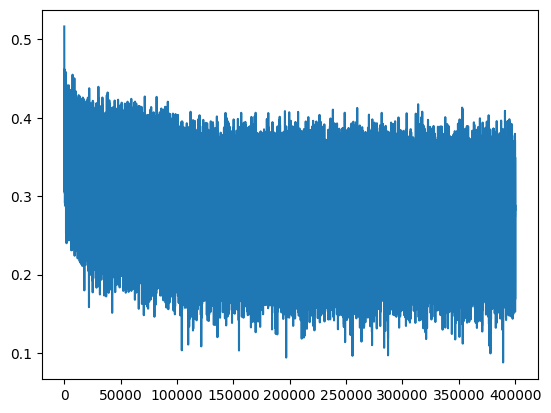

In [18]:
plt.plot(stepi, lossi)

In [19]:
# evaluate the overall loss on dev
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 40) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)

In [20]:
loss.item()

2.0620429515838623

Test on test set

In [17]:
emb = C[Xtest]
h = torch.tanh(emb.view(-1, 40) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytest)
loss

tensor(2.0526, grad_fn=<NllLossBackward0>)

Use the model to generate words:

In [25]:
block_size = 4
for _ in range(20):
  out = []
  context = [0] * block_size
  while True:
    emb = C[torch.tensor([context])] # (1, block_size, d)
    h = torch.tanh(emb.view(1, -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break


  print(''.join(itos[i] for i in out))

cardell.
jameela.
thaviah.
lungan.
xanylea.
adilynco.
nomotestha.
ridrian.
zelynn.
stina.
xammres.
miti.
lanor.
malak.
luise.
vaden.
gitziel.
kameela.
benica.
bent.


Visualize the character embeddings

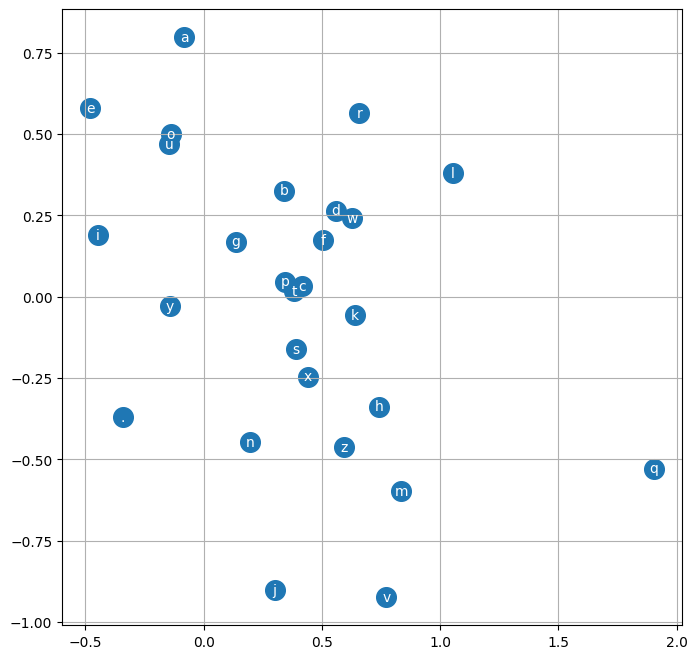

In [100]:
plt.figure(figsize=(8,8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
  plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')